# ToolFinder — Live Evidence Notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DimiChatzipavlis/ToolFinder/blob/main/notebooks/02_toolfinder_live.ipynb)

This notebook is the runnable companion to `reports/report.md`. It works in
two modes:

- **Google Colab:** clones the repository from GitHub and installs dependencies
  (first run takes a few minutes), then everything below runs live.
- **Local checkout:** detects the repo and runs directly.

What runs **live** here: the deployed router on the real 30-tool GitHub MCP
corpus (routing, scores, abstention), the lexical baselines reproduced
against the committed results, an exact-vs-HNSW timing microbenchmark, and —
if a GPU is available — a 2-epoch bi-encoder fine-tune with before/after
accuracy. The full multi-seed results are loaded from
`experiments/results/` (regenerable via `python experiments/run_all.py`).

In [1]:
import os
import subprocess
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
if not Path("toolfinder").exists():
    print("cloning ToolFinder from GitHub...")
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/DimiChatzipavlis/ToolFinder.git"], check=True)
    os.chdir("ToolFinder")

try:
    import faiss  # noqa: F401
    import matplotlib  # noqa: F401
    import pandas  # noqa: F401
    import sentence_transformers  # noqa: F401
    import sklearn  # noqa: F401
except ImportError:
    print("installing ToolFinder + experiment dependencies (a few minutes on Colab)...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[experiments]"], check=True)

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
print("repo root:", REPO_ROOT)

C:\Users\dimit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo root: C:\Users\dimit\Desktop\GEORGAML\ToolFinder


## 1. The router, live

We ingest the 30 real GitHub MCP tool schemas and route natural-language
intents. MiniLM is used here for CPU speed; the runtime default (MPNet) behaves
identically architecturally. Note the **exact flat index** — see section 4 for
why approximate search buys nothing at these catalog sizes.

In [2]:
import json
from toolfinder import UniversalMCPRouter, to_openai_tools

corpus = json.loads((REPO_ROOT / "experiments/data/corpus.json").read_text(encoding="utf-8"))
router = UniversalMCPRouter(model_name="sentence-transformers/all-MiniLM-L6-v2")
for tool, entry in corpus.items():
    schema = entry["schema"]
    router.add_tool(
        {"name": schema["name"], "description": schema["description"], "inputSchema": schema["inputSchema"]},
        server_name=entry["server"],
    )
count = router.build_index()
print(f"indexed {count} tools | index type: {type(router.faiss_index).__name__}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6590.09it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


indexed 30 tools | index type: IndexFlatIP


In [3]:
for query in [
    "open a pull request to merge the auth cleanup work",
    "who is on the platform team?",
    "I need the contents of src/config.yaml from the repo",
]:
    results = router.route_top_k(query, k=3)
    formatted = ", ".join(f"{r.tool_name} ({r.score:.3f})" for r in results)
    print(f"{query!r}\n  -> {formatted}\n")

print("bindable schema for the last top hit:")
print(json.dumps(to_openai_tools(results[:1])[0]["function"]["name"], indent=2))

Ambiguous semantic routing for query 'who is on the platform team?' (score1=0.3081, score2=0.3007, margin=0.0073)


'open a pull request to merge the auth cleanup work'
  -> merge_pull_request (0.449), create_pull_request (0.367), get_copilot_job_status (0.363)

'who is on the platform team?'
  -> get_team_members (0.308), get_teams (0.301)

'I need the contents of src/config.yaml from the repo'
  -> get_file_contents (0.473), get_commit (0.453), get_latest_release (0.435)

bindable schema for the last top hit:
"get_file_contents"


### Scores around the abstention threshold

The router abstains when the best similarity falls below `min_cosine_similarity`.
The honest story (quantified in `experiments/results/ood_eval.json`) is that
in-scope and out-of-scope queries occupy different score ranges but the
separation is imperfect — chitchat sits far below in-distribution scores, while
near-miss requests overlap them. The cell shows raw top-1 scores against the
threshold so you can see the margin, not just the verdict.

In [4]:
probe_queries = [
    ("in-scope ", "list the open issues mentioning memory leaks"),
    ("in-scope ", "fork the analytics repository to my account"),
    ("oo-scope ", "what's the weather in Athens tomorrow?"),
    ("oo-scope ", "play my focus playlist"),
]
tau = router.config.min_cosine_similarity
print(f"threshold tau = {tau}")
for label, query in probe_queries:
    top = router.route_top_k(query, k=1)
    if top:
        verdict = "route" if top[0].score >= tau else "abstain"
        print(f"[{label}] {query!r:55s} top1={top[0].tool_name:24s} score={top[0].score:.3f} -> {verdict}")
    else:
        print(f"[{label}] {query!r:55s} -> abstain (below threshold)")

threshold tau = 0.15
[in-scope ] 'list the open issues mentioning memory leaks'          -> abstain (below threshold)
[in-scope ] 'fork the analytics repository to my account'           top1=fork_repository          score=0.384 -> route
[oo-scope ] "what's the weather in Athens tomorrow?"                -> abstain (below threshold)
[oo-scope ] 'play my focus playlist'                                -> abstain (below threshold)


## 2. Baselines reproduced live

BM25 and TF-IDF run in seconds on CPU; we evaluate them on the leakage-controlled
regime-1 test split and check the numbers against the committed results file —
the table in the report is reproducible, not copy-pasted.

In [5]:
import pandas as pd
from experiments.baselines import Bm25Ranker, TfidfRanker
from experiments.evaluation import metrics
from experiments.representation import represent_raw

queries = pd.read_csv(REPO_ROOT / "experiments/data/queries_with_scenarios.csv").set_index("query_id")
split = json.loads((REPO_ROOT / "experiments/data/splits/regime1_unseen_queries.json").read_text(encoding="utf-8"))
corpus_tools = sorted(corpus)
corpus_texts = [represent_raw(corpus[t]["schema"]) for t in corpus_tools]
test_ids = split["test"]
anchors = queries.loc[test_ids, "anchor"].tolist()
truths = queries.loc[test_ids, "tool"].tolist()

live = {}
for system in (Bm25Ranker(corpus_tools, corpus_texts),
               TfidfRanker(corpus_tools, corpus_texts, analyzer="char_wb", ngram_range=(3, 5))):
    rankings = [system.rank(a) for a in anchors]
    ranks = metrics.ranks_from_rankings(rankings, truths)
    live[system.name] = round(float(metrics.recall_at_k(ranks, 1).mean()), 4)

committed_path = REPO_ROOT / "experiments/results/main_eval.json"
committed = json.loads(committed_path.read_text(encoding="utf-8")) if committed_path.exists() else None
print(f"{'system':12s} {'live R@1':>9s} {'committed':>10s}")
for name, value in live.items():
    committed_value = (
        committed["regimes"]["regime1_unseen_queries"][name]["recall@1"]["mean"] if committed else float("nan")
    )
    match = "OK" if committed and abs(value - committed_value) < 1e-6 else ""
    print(f"{name:12s} {value:9.4f} {committed_value:10.4f}  {match}")

system        live R@1  committed
bm25            0.5694     0.5694  OK
tfidf_char      0.4861     0.4861  OK


## 3. The committed evidence

Full multi-seed results across the three regimes (unseen queries / unseen tools /
unseen servers), produced by `experiments/run_all.py`.

In [6]:
def regime_frame(regime: str) -> pd.DataFrame:
    rows = []
    for name, block in committed["regimes"][regime].items():
        if "recall@1" not in block or name.startswith("random"):
            continue
        entry = {"system": name, "R@1": block["recall@1"]["mean"], "R@3": block["recall@3"]["mean"], "MRR": block["mrr"]["mean"]}
        rows.append(entry)
    return pd.DataFrame(rows).sort_values("R@1", ascending=False).reset_index(drop=True)

for regime in committed["regimes"]:
    print(f"==== {regime} ====")
    display(regime_frame(regime).head(12))

==== regime1_unseen_queries ====


,system,R@1,R@3,MRR
0,ft_mpnet_seed13,1.0000,1.0,1.0000
1,ft_mpnet_seed42,1.0000,1.0,1.0000
2,ft_mpnet_seed1337,1.0000,1.0,1.0000
3,ft_mpnet (avg over seeds),1.0000,1.0,1.0000
4,ft_bge_seed1337,0.9931,1.0,0.9965
5,ft_minilm_seed42,0.9931,1.0,0.9965
6,ft_bge_seed42,0.9931,1.0,0.9965
7,ft_bge (avg over seeds),0.9908,1.0,0.9954
8,ft_minilm (avg over seeds),0.9884,1.0,0.9942
9,ft_minilm_seed13,0.9861,1.0,0.9931


==== regime2_unseen_tools ====


,system,R@1,R@3,MRR
0,ft_mpnet_seed1337,0.9160,1.0000,0.9580
1,ft_mpnet_seed13,0.9160,1.0000,0.9578
2,ft_mpnet (avg over seeds),0.9151,1.0000,0.9575
3,ft_minilm_seed1337,0.9133,1.0000,0.9549
4,ft_mpnet_seed42,0.9133,1.0000,0.9567
5,ft_minilm_seed13,0.9093,1.0000,0.9529
6,ft_minilm (avg over seeds),0.9093,0.9996,0.9528
7,ft_minilm_seed42,0.9053,0.9987,0.9506
8,ft_minilm+ce_rerank_seed13,0.8720,0.9800,0.9249
9,ft_bge_seed42,0.8680,0.9973,0.9269


==== regime3_unseen_servers ====


,system,R@1,R@3,MRR
0,ft_mpnet_seed42,0.7333,0.9436,0.8363
1,ft_mpnet (avg over seeds),0.7265,0.9419,0.8313
2,ft_mpnet_seed1337,0.7231,0.9385,0.8266
3,ft_mpnet_seed13,0.7231,0.9436,0.8310
4,ft_minilm_seed13,0.6769,0.8872,0.7813
5,ft_minilm_seed42,0.6667,0.8615,0.7722
6,ft_minilm (avg over seeds),0.6667,0.8735,0.7750
7,ft_minilm_seed1337,0.6564,0.8718,0.7715
8,ft_bge_seed13,0.6513,0.8615,0.7674
9,ft_bge (avg over seeds),0.6444,0.8632,0.7608


fig_main_results.png


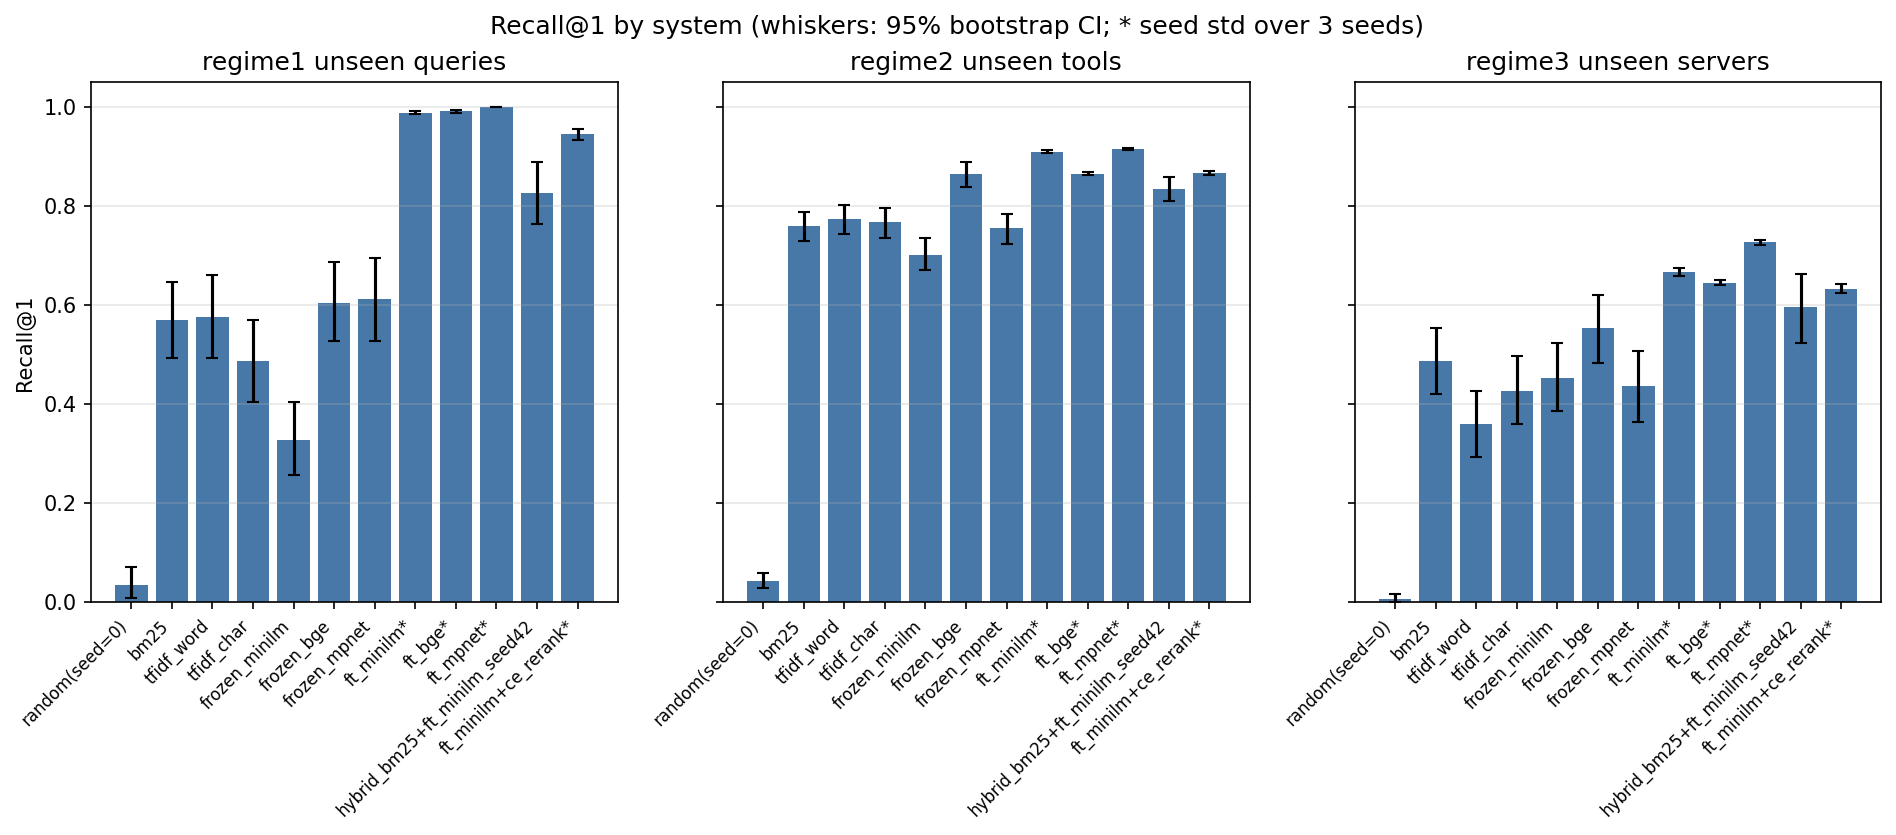

fig_leakage_audit.png


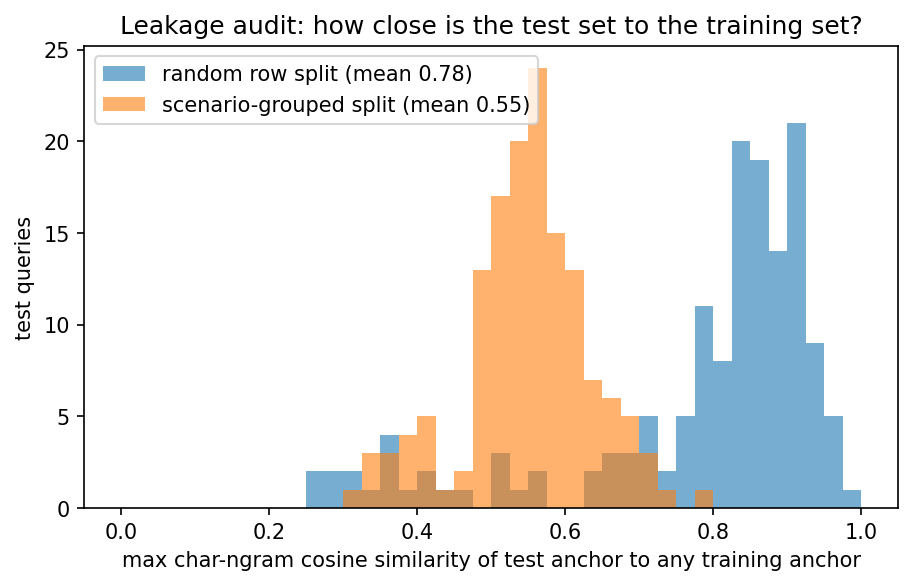

fig_loss_curves.png


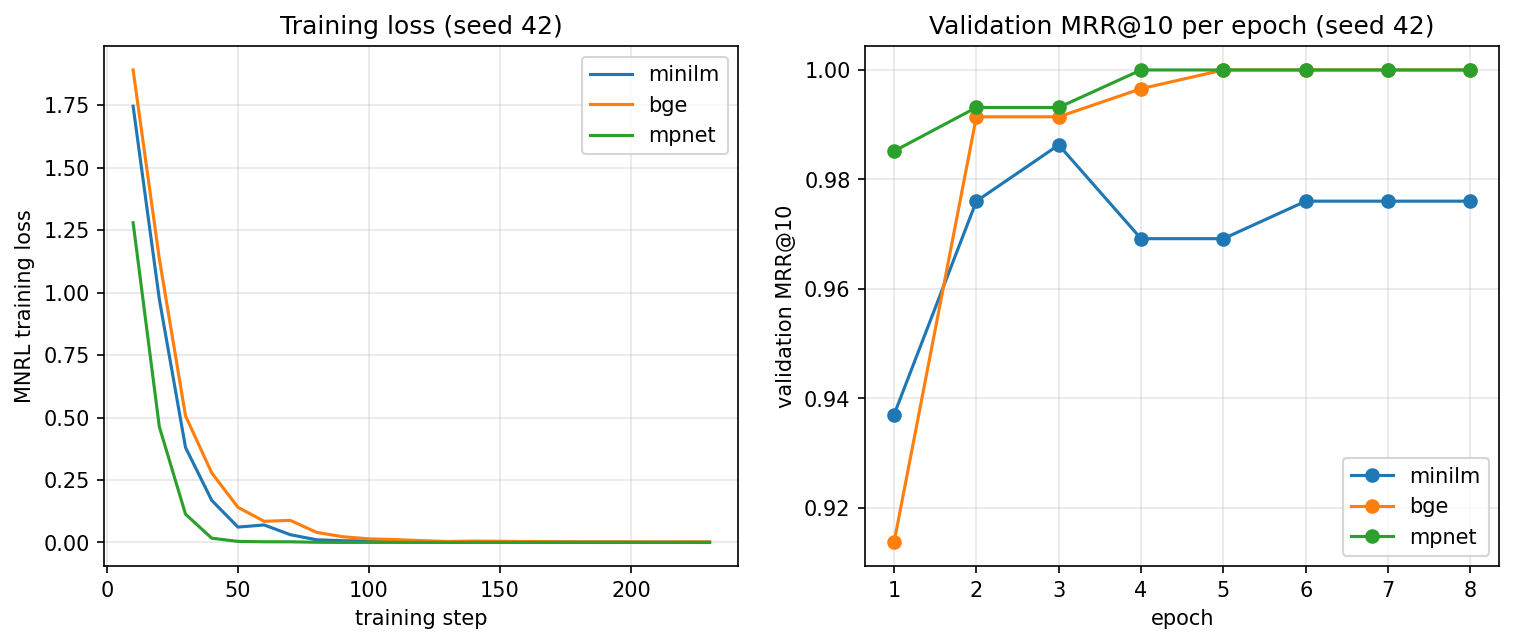

fig_threshold_sweep.png


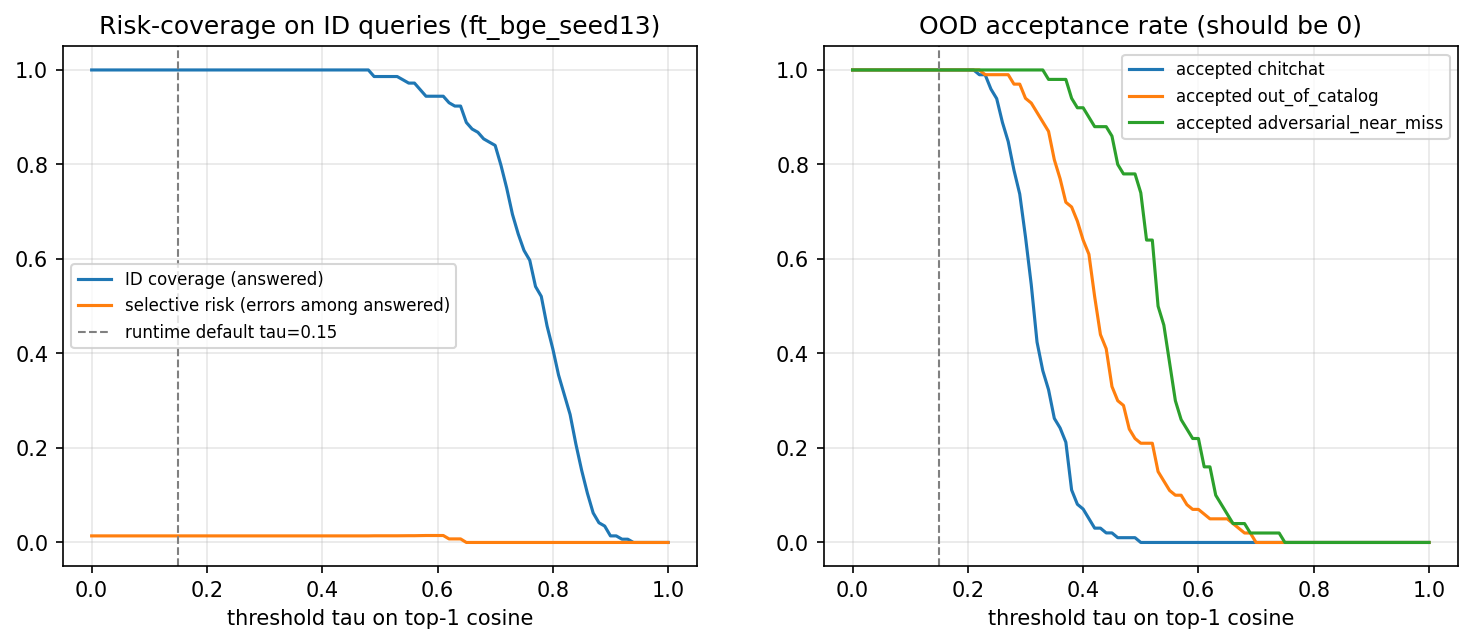

fig_scaling.png


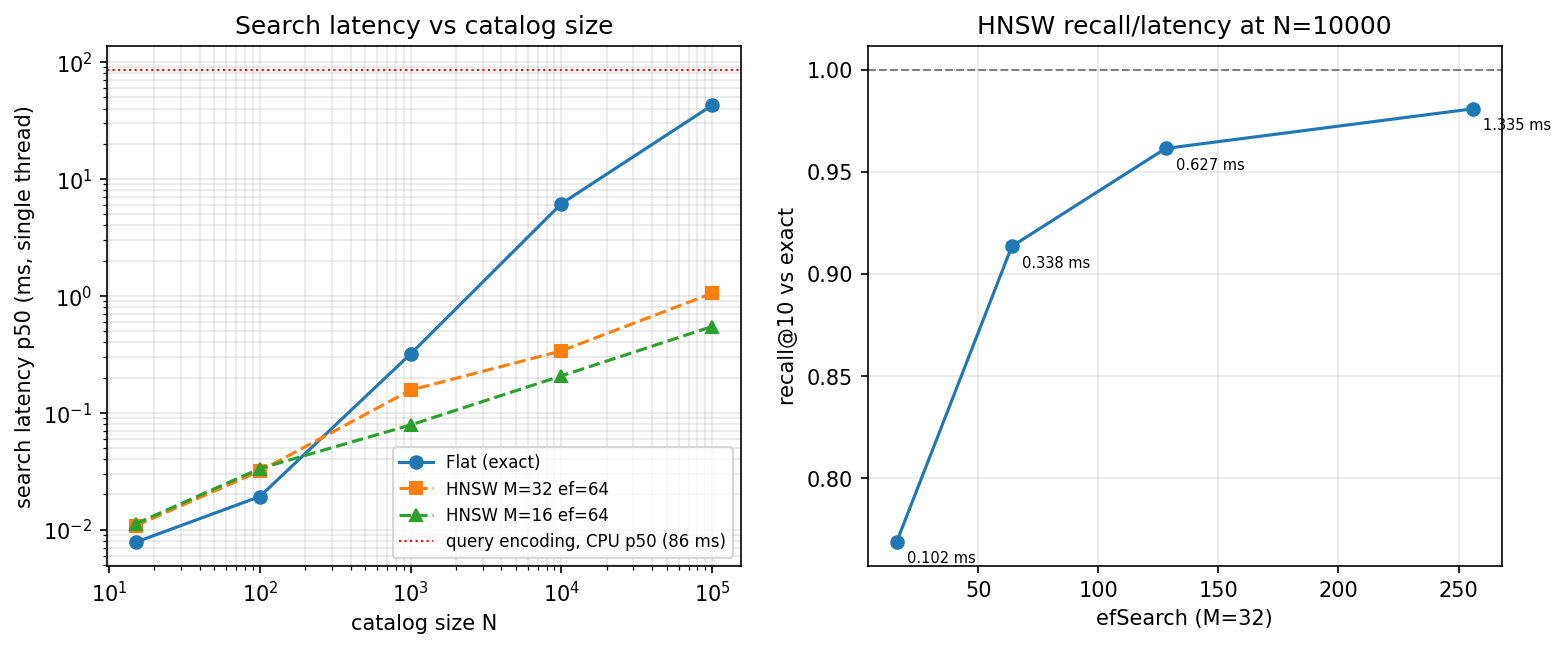

In [7]:
from IPython.display import Image, display
for figure_name in [
    "fig_main_results.png",
    "fig_leakage_audit.png",
    "fig_loss_curves.png",
    "fig_threshold_sweep.png",
    "fig_scaling.png",
]:
    figure_path = REPO_ROOT / "experiments/results/figures" / figure_name
    if figure_path.exists():
        print(figure_name)
        display(Image(str(figure_path)))

## 4. Exact vs approximate search, live

The report's scaling study runs to 100k vectors; here is the small live version.
At tool-catalog sizes, exact flat inner-product search is *faster* than HNSW
graph traversal — and exact. Query encoding (tens of ms) dominates either.

In [8]:
import time
import numpy as np
import faiss
from experiments.benchmarks.scaling_bench import generate_synthetic_schemas
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
documents = [represent_raw(corpus[t]["schema"]) for t in corpus_tools] + generate_synthetic_schemas(1000 - 30)
embeddings = encoder.encode(documents, batch_size=64, convert_to_numpy=True, show_progress_bar=False).astype("float32")
faiss.normalize_L2(embeddings)
query_vectors = encoder.encode(anchors[:50], convert_to_numpy=True, show_progress_bar=False).astype("float32")
faiss.normalize_L2(query_vectors)
faiss.omp_set_num_threads(1)

print(f"{'N':>6s} {'flat p50 (ms)':>14s} {'hnsw p50 (ms)':>14s} {'hnsw recall@10':>15s}")
for n in (15, 100, 1000):
    sub = embeddings[:n]
    flat = faiss.IndexFlatIP(sub.shape[1]); flat.add(sub)
    hnsw = faiss.IndexHNSWFlat(sub.shape[1], 32, faiss.METRIC_INNER_PRODUCT); hnsw.hnsw.efSearch = 64; hnsw.add(sub)
    _, truth_ids = flat.search(query_vectors, 10)
    timings = {}
    for label, index in (("flat", flat), ("hnsw", hnsw)):
        per_query = []
        for repeat in range(10):
            for i in range(len(query_vectors)):
                start = time.perf_counter()
                index.search(query_vectors[i:i+1], 10)
                per_query.append((time.perf_counter() - start) * 1000)
        timings[label] = float(np.percentile(per_query, 50))
    _, approx_ids = hnsw.search(query_vectors, 10)
    recall = float(np.mean([len(set(a) & set(t)) / 10 for a, t in zip(approx_ids, truth_ids)]))
    print(f"{n:6d} {timings['flat']:14.4f} {timings['hnsw']:14.4f} {recall:15.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 27425.93it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


     N  flat p50 (ms)  hnsw p50 (ms)  hnsw recall@10
    15         0.0060         0.0060          1.0000
   100         0.0072         0.0185          1.0000
  1000         0.0425         0.0501          0.9980


## 5. Live fine-tuning (GPU only)

If this runtime has a GPU (Colab: Runtime → Change runtime type → GPU), the cell
below fine-tunes MiniLM for two epochs on the regime-1 training scenarios with
the no-duplicates batch sampler, then re-evaluates on the held-out test split —
the frozen-vs-fine-tuned delta is the report's headline effect, reproduced in
~2 minutes. On CPU the cell skips itself.

In [9]:
import torch

if not torch.cuda.is_available():
    print("no GPU in this runtime - skipping the live fine-tune (full results are in section 3)")
else:
    from datasets import Dataset
    from sentence_transformers import (SentenceTransformer, SentenceTransformerTrainer,
                                       SentenceTransformerTrainingArguments, losses)
    from sentence_transformers.training_args import BatchSamplers
    from experiments.baselines import EncoderRanker

    text_by_tool = dict(zip(corpus_tools, corpus_texts))
    train_df = queries.loc[split["train"]]
    train_dataset = Dataset.from_dict({
        "anchor": train_df["anchor"].tolist(),
        "positive": [text_by_tool[t] for t in train_df["tool"]],
    })

    def recall_at_1(model_path_or_obj) -> float:
        ranker = EncoderRanker("eval", model_path_or_obj, corpus_tools, corpus_texts)             if isinstance(model_path_or_obj, str) else model_path_or_obj
        rankings = ranker.rank_batch(anchors)
        ranks = metrics.ranks_from_rankings(rankings, truths)
        return float(metrics.recall_at_k(ranks, 1).mean())

    frozen_r1 = recall_at_1("sentence-transformers/all-MiniLM-L6-v2")

    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cuda")
    model.max_seq_length = 256
    trainer = SentenceTransformerTrainer(
        model=model,
        args=SentenceTransformerTrainingArguments(
            output_dir="/tmp/live_ft", num_train_epochs=2, per_device_train_batch_size=16,
            learning_rate=2e-5, warmup_ratio=0.1, fp16=True,
            batch_sampler=BatchSamplers.NO_DUPLICATES, save_strategy="no",
            logging_steps=20, report_to="none", seed=42,
        ),
        train_dataset=train_dataset,
        loss=losses.MultipleNegativesRankingLoss(model),
    )
    trainer.train()
    model.save("/tmp/live_ft/final")
    tuned_r1 = recall_at_1("/tmp/live_ft/final")
    print(f"\nRecall@1 on regime-1 test: frozen {frozen_r1:.4f} -> fine-tuned (2 epochs) {tuned_r1:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4708.18it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8612.71it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.77it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.77it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6591.90it/s]


Recall@1 on regime-1 test: frozen 0.3264 -> fine-tuned (2 epochs) 0.9722


## Where to go next

- Full report (auto-generated from results): `reports/report.md`
- Pipeline documentation and stage map: `experiments/README.md`
- Dataset provenance and biases: `experiments/data/DATASET_CARD.md`
- Security posture: `SECURITY.md`